In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#Quick EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


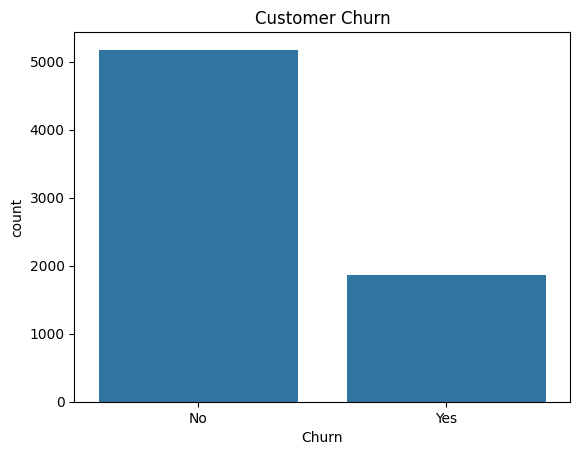

In [7]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn")
plt.show()

#Explore Important Features

#contract type

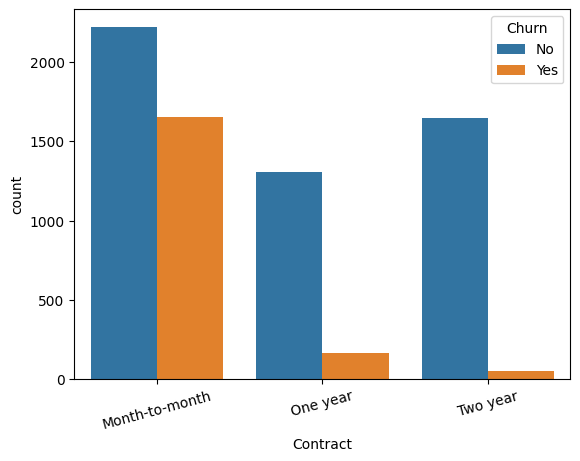

In [8]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=15)
plt.show()

#Tenure

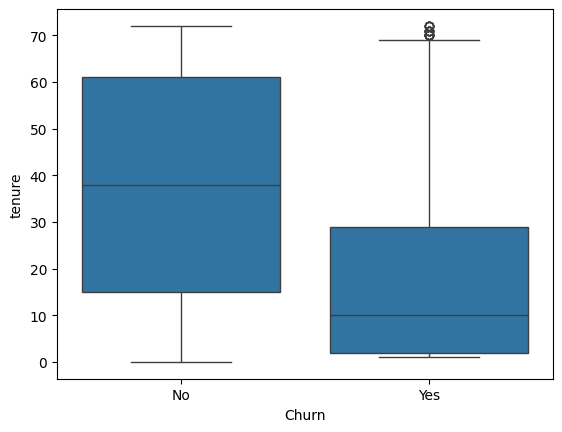

In [9]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

#Monthly Charges

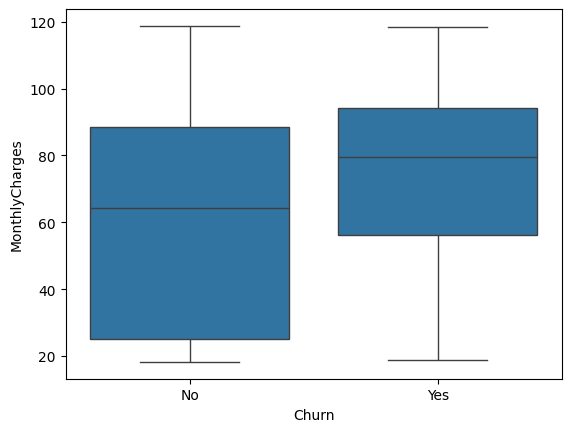

In [10]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

#Correlation Heatmap

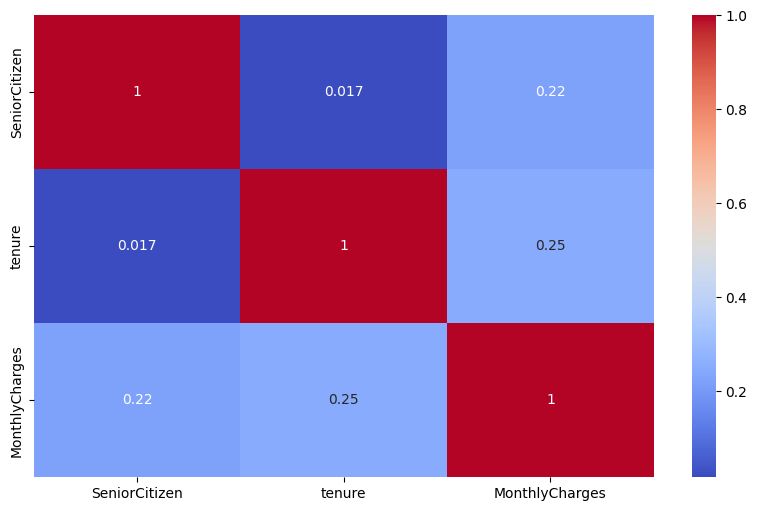

In [11]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

#Data Cleaning

In [12]:
df = df.drop("customerID", axis=1)

In [13]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [14]:
df = pd.get_dummies(df, drop_first=True)

#Define Features

In [15]:
X = df.drop("Churn_Yes", axis=1)

y = df["Churn_Yes"]

#Train Test

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Logistic Regression

In [17]:
lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

#Accuracy

In [18]:
print("Logistic Regression Accuracy")

print(
    accuracy_score(
        y_test,
        lr_pred
    )
)

print(classification_report(
    y_test,
    lr_pred
))

Logistic Regression Accuracy
0.8218594748048261
              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



#Decision Trees

In [19]:
tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(
    X_train,
    y_train
)

tree_pred = tree.predict(X_test)

In [20]:
print("Decision Tree Accuracy")

print(
    accuracy_score(
        y_test,
        tree_pred
    )
)

print(classification_report(
    y_test,
    tree_pred
))

Decision Tree Accuracy
0.7097232079489
              precision    recall  f1-score   support

       False       0.80      0.80      0.80      1036
        True       0.45      0.45      0.45       373

    accuracy                           0.71      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409



#Comparing Models

In [21]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy":[

        accuracy_score(
            y_test,
            lr_pred
        ),

        accuracy_score(
            y_test,
            tree_pred
        )
    ]

})

comparison

,Model,Accuracy
0,Logistic Regression,0.821859
1,Decision Tree,0.709723


#Class Imbalance

In [22]:
df["Churn_Yes"].value_counts(normalize=True)

,proportion
Churn_Yes,
False,0.73463
True,0.26537


**The dataset is moderately imbalanced because customers who do not churn are more common than customers who churn. This imbalance may bias the model toward predicting the majority class. In future work, techniques such as class weighting, SMOTE, or undersampling could be applied to improve performance on the minority class.**

#Feature imp

In [23]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":tree.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(3)

,Feature,Importance
1,tenure,0.204891
2,MonthlyCharges,0.202813
3,TotalCharges,0.196676


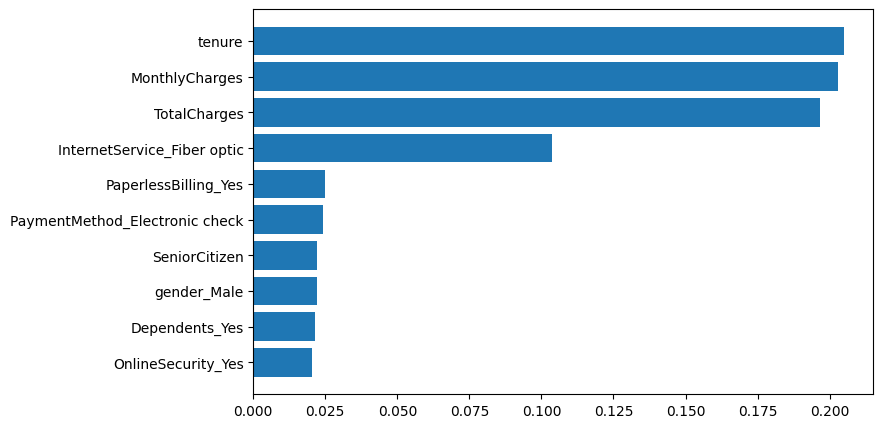

In [24]:
top = importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.gca().invert_yaxis()

plt.show()

#Summary
**The model was built to identify customers who are likely to leave the company. Both Logistic Regression and Decision Tree models were evaluated, with Logistic Regression often providing more stable performance while the Decision Tree offered better interpretability. The most influential factors affecting customer churn included contract type, tenure, and monthly charges. These insights can help the company target high-risk customers with retention strategies, reducing customer loss and improving long-term revenue.**

#Week 4_Task 2
#Ensemble Learning: Random Forest vs XGBoost

In [25]:
!pip install xgboost

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report

#Training Random forest

In [27]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7892122072391767


#Training Xgboost

In [28]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.794180269694819


#Comparing Models

In [30]:
lr_accuracy = accuracy_score(y_test, lr_pred)
dt_accuracy = accuracy_score(y_test, tree_pred)

In [31]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.821859
1,Decision Tree,0.709723
2,Random Forest,0.789212
3,XGBoost,0.794180


#Random Forest Feature Imp

In [32]:
importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by="Importance",
    ascending=False
)

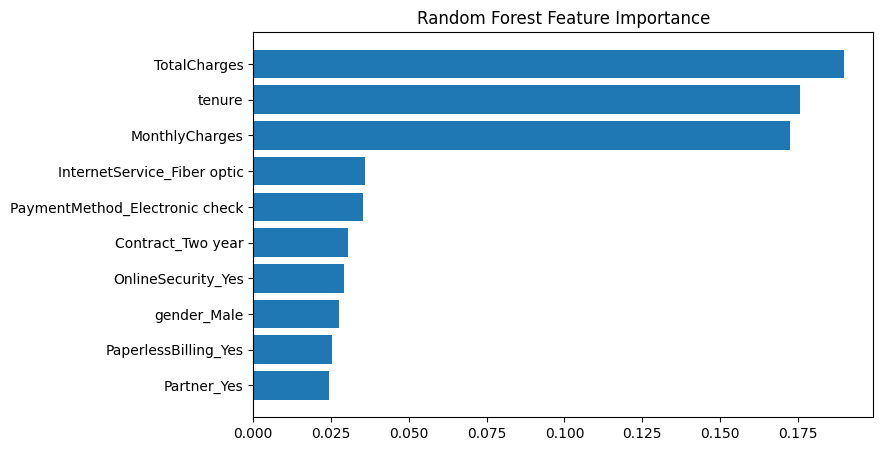

In [33]:
top = importance_rf.head(10)

plt.figure(figsize=(8,5))
plt.barh(top["Feature"], top["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.show()

#Xgboost Feature imp

In [34]:
importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

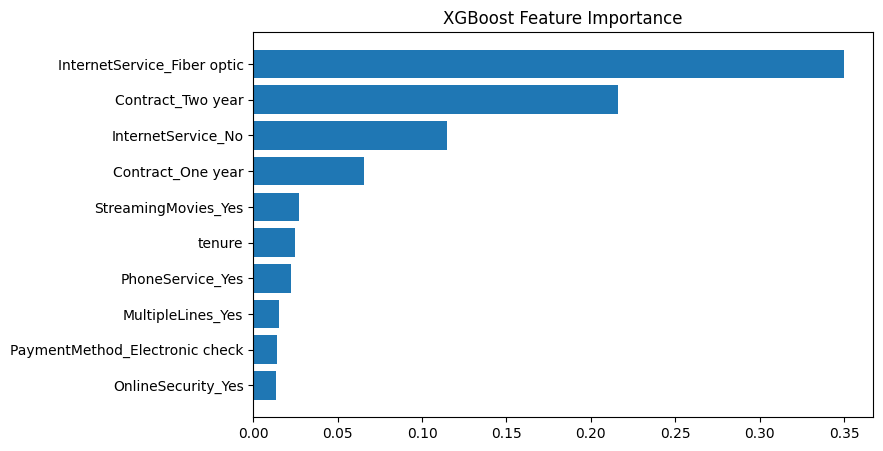

In [35]:
top = importance_xgb.head(10)

plt.figure(figsize=(8,5))
plt.barh(top["Feature"], top["Importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()

**Random Forest builds many decision trees independently and combines their predictions using majority voting for classification or averaging for regression. XGBoost builds trees sequentially, where each new tree focuses on correcting the mistakes made by previous trees. Because of this boosting approach, XGBoost often achieves higher accuracy but typically requires more computation. Random Forest is generally simpler and less prone to overfitting, while XGBoost is highly optimized for predictive performance**

| Model | Accuracy |
|---------|---------:|
| Logistic Regression | 82% |
| Decision Tree | 70% |
| Random Forest | 78% |
| XGBoost | 79% |